Question 1: What is inductive reasoning? Deductive reasoning? Give an example of each, different from the examples given in class.



Inductive reasoning means observing and analysing specific trends or patterns to make a general conclusion. For example, observing that oranges, lemons, and strawberries all contain vitamin C may lead to the general conclusion that fruits are a good source of vitamin C.

Deductive reasoning is the opposite, it moves from general rules and apply it to a specific scenario to make a specific conclusion. For example, excessive social media use is harmful for the mental health. Tiktok is a form of social media use. Therefore, excessive scrolling on TikTok can be harmful to mental health.

Question 2: Preprocess Dataset

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [293]:
arrhythmia_df = pd.read_csv("arrhythmia.csv")
arrhythmia_df.head()

,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
0,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
1,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
2,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
3,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
4,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14


In [294]:
arrhythmia_df.dtypes

75         int64
0          int64
190        int64
80         int64
91         int64
          ...   
0.9.2    float64
2.9.1    float64
23.3     float64
49.4     float64
8          int64
Length: 280, dtype: object

In [295]:
arrhythmia_df.columns = arrhythmia_df.columns.str.replace('.', '_', regex=False)
arrhythmia_df.head()

,75,0,190,80,91,193,371,174,121,-16,...,0_0_38,9_0,-0_9,0_0_39,0_0_40,0_9_2,2_9_1,23_3,49_4,8
0,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
1,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
2,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
3,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
4,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14


In [296]:
arrhythmia_df.isnull().values.any()

np.False_

In [297]:
arrhythmia_df = arrhythmia_df.replace('?', np.nan)
arrhythmia_df = arrhythmia_df.apply(pd.to_numeric, errors='coerce') 
arrhythmia_df = arrhythmia_df.fillna(arrhythmia_df.median())

In [298]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(arrhythmia_df)

In [299]:
arrhythmia_df.isnull().sum()

75       0
0        0
190      0
80       0
91       0
        ..
0_9_2    0
2_9_1    0
23_3     0
49_4     0
8        0
Length: 280, dtype: int64

Question 3:

In [300]:
from sklearn.model_selection import train_test_split

last_col = arrhythmia_df.columns[-1]

X = arrhythmia_df.drop(columns=last_col)
y = arrhythmia_df[last_col]
y = (y != 1).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=50)
                                                    

In [301]:
model = tree.DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=17,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=43)

model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [302]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.74      0.75        74
           1       0.70      0.73      0.71        62

    accuracy                           0.74       136
   macro avg       0.73      0.73      0.73       136
weighted avg       0.74      0.74      0.74       136



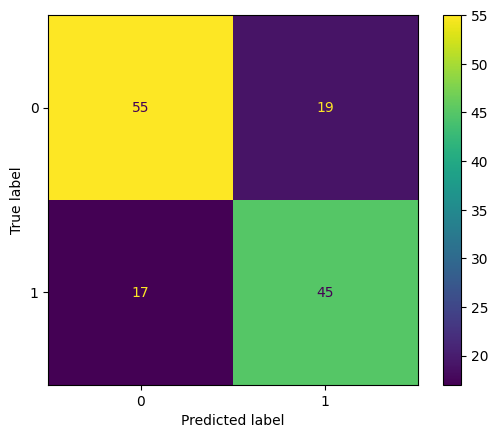

In [303]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [304]:
Precision_original = 45/(45+19)
Recall_original = 45/(45+17)

print("Precision =", Precision_original, "Recall =", Recall_original)

Precision = 0.703125 Recall = 0.7258064516129032


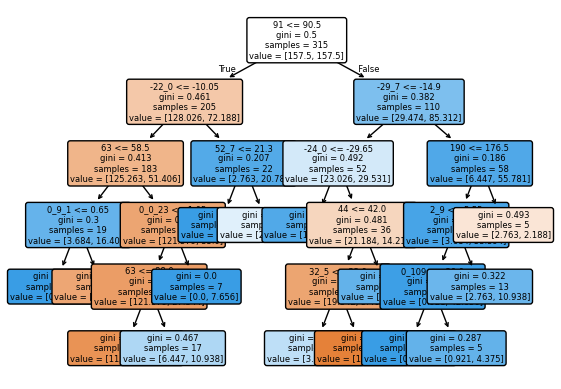

<Figure size 640x480 with 0 Axes>

In [305]:
import matplotlib.pyplot as plt
tree.plot_tree(model, feature_names = list(X.columns),
                filled = True, fontsize=6, rounded= True)

plt.show()
plt.savefig("tree.svg")

When I first process the data after preprocessing, I realized this dataset has a lot of classes, so I have to changed to binary classifiaction. I tune this model by adjusted max_depth(how many levels the tree can have) to different values like 2,5,7, and 10. It turns out the model works best for the value 5. I have tried to change some variables, but the current one gave the best result. 

Question 4:

In [306]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)

param_gd = {
    'n_estimators': [100,200],
    'max_depth': [10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2],
    'class_weight': ['balanced']}

gd = GridSearchCV(
    rf,
    param_gd,
    cv=5,
    scoring='f1',
    n_jobs=-1)

gd.fit(X_train, y_train)
best_model = gd.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", gd.best_params_)
print(classification_report(y_test, y_pred))

Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        74
           1       0.91      0.81      0.85        62

    accuracy                           0.88       136
   macro avg       0.88      0.87      0.87       136
weighted avg       0.88      0.88      0.87       136



The result that I got for this model for the first time trying is really good, which makes me so surprise. I did not make any additional tune on this model.

Question 5:

In [307]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [308]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.5, 1],
    'colsample_bytree': [0.5, 1]}

grid = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print(classification_report(y_test, y_pred))

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [23:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1}
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        74
           1       0.93      0.85      0.89        62

    accuracy                           0.90       136
   macro avg       0.91      0.90      0.90       136
weighted avg       0.91      0.90      0.90       136



I tune the model by changing the n_estimators from 200-300 to 100-200. I think it help boost the precision and recall. Then, I test different the input and I figure out that the closer the testing range (0.8-1) input for subsample and colsample_by tree, and it gives the better result. I think it's balance randomness with sufficient information per tree to avoid over or underfitting. However, adjusting learning_rate did not significantly affect performance, it's maybe because the number of boosting feature and data sampling had a bigger impact for this dataset.